<a href="https://colab.research.google.com/github/serminoymakargul/odev/blob/main/dinamik%20_fiyatland%C4%B1rma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

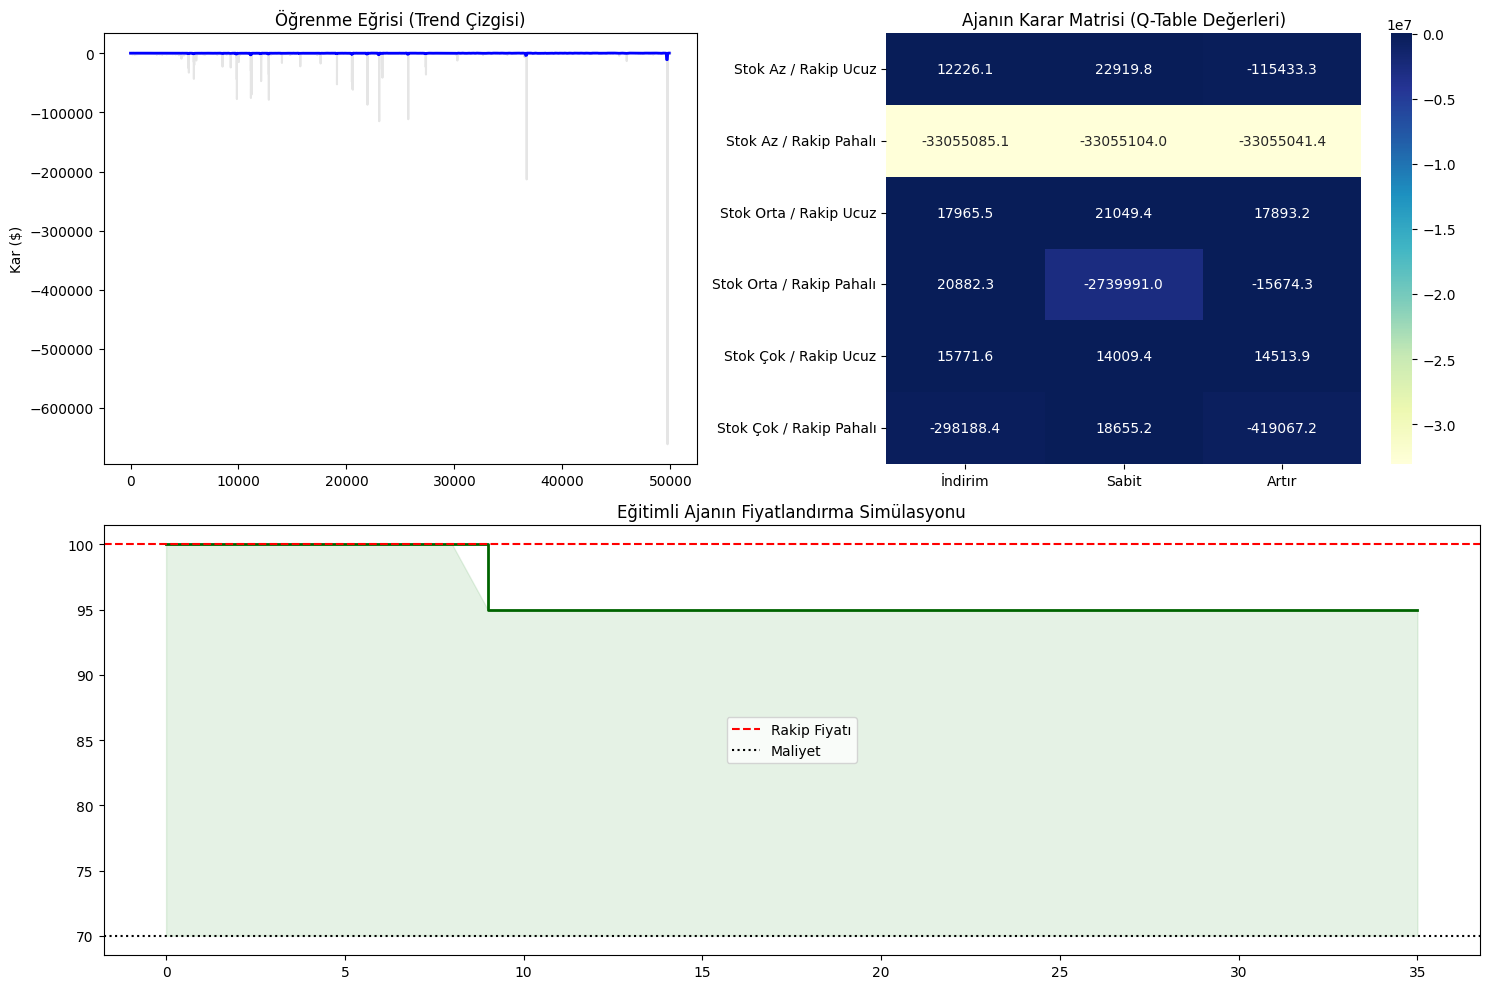

   DİNAMİK FİYATLANDIRMA AJAN RAPORU
1. Performans Artışı: %40.39
2. Ortalama Bölüm Karı: 513.83 $
3. Ajanın Temel Keşfi: Stok çokken fiyat düşürmeyi öğrendi.


In [7]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. PARAMETRELER ---
STOK_KAPASITESI = 20
RAKIP_FIYAT = 100
MALIYET = 70
DEPO_MALIYETI = 1
BOLUM_SAYISI = 50000 # Bölüm sayısı artırıldı

alpha, gamma = 0.15, 0.98 # Alpha ve Gamma değerleri güncellendi
epsilon, epsilon_decay, min_epsilon = 1.0, 0.9999, 0.01 # Epsilon decay yavaşlatıldı

q_table = np.zeros((6, 3))

def get_state(stok, fiyat):
    s_stok = 0 if stok <= 5 else (1 if stok <= 15 else 2)
    s_rakip = 0 if fiyat < RAKIP_FIYAT else 1
    return s_stok * 2 + s_rakip

def talep_olasiligi(bizim_fiyat, rakip_fiyat):
    # np.exp'ye giden değeri kırpma (clip) işlemi ekleyerek overflow uyarısını önle
    exp_input = np.clip(0.15 * (bizim_fiyat - rakip_fiyat), -50, 50) # Değerleri -50 ile 50 arasına sınırlıyoruz
    return 1 / (1 + np.exp(exp_input))

# --- 2. EĞİTİM ---
odul_gecmisi = []
for ep in range(BOLUM_SAYISI):
    stok, toplam_odul, fiyat = STOK_KAPASITESI, 0, 100
    while stok > 0:
        s = get_state(stok, fiyat)
        a = random.randint(0, 2) if random.random() < epsilon else np.argmax(q_table[s])

        if a == 0: fiyat *= 0.95
        elif a == 2: fiyat *= 1.05

        if random.random() < talep_olasiligi(fiyat, RAKIP_FIYAT):
            toplam_odul += (fiyat - MALIYET)
            stok -= 1
        else:
            toplam_odul -= DEPO_MALIYETI

        q_table[s, a] += alpha * (toplam_odul + gamma * np.max(q_table[get_state(stok, fiyat)]) - q_table[s, a])

    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    odul_gecmisi.append(toplam_odul)

# --- 3. ANALİZ VE GÖRSELLEŞTİRME PANELİ ---
plt.figure(figsize=(15, 10))

# 1. Grafik: Öğrenme Performansı
plt.subplot(2, 2, 1)
plt.plot(odul_gecmisi, alpha=0.2, color='gray')
mv_avg = np.convolve(odul_gecmisi, np.ones(100)/100, mode='valid')
plt.plot(mv_avg, color='blue', linewidth=2)
plt.title("Öğrenme Eğrisi (Trend Çizgisi)")
plt.ylabel("Kar ($)")

# 2. Grafik: Q-Table Isı Haritası (Ajanın Strateji Haritası)
plt.subplot(2, 2, 2)
durum_etiketleri = [
    "Stok Az / Rakip Ucuz", "Stok Az / Rakip Pahalı",
    "Stok Orta / Rakip Ucuz", "Stok Orta / Rakip Pahalı",
    "Stok Çok / Rakip Ucuz", "Stok Çok / Rakip Pahalı"
]
aksiyon_etiketleri = ["İndirim", "Sabit", "Artır"]
sns.heatmap(q_table, annot=True, fmt=".1f", cmap="YlGnBu",
            xticklabels=aksiyon_etiketleri, yticklabels=durum_etiketleri)
plt.title("Ajanın Karar Matrisi (Q-Table Değerleri)")

# 3. Grafik: Bir Satış Döngüsü Simülasyonu
plt.subplot(2, 1, 2)
test_stok, test_fiyat, fiyatlar = STOK_KAPASITESI, 100, [100]
while test_stok > 0:
    a = np.argmax(q_table[get_state(test_stok, test_fiyat)])
    if a == 0: test_fiyat *= 0.95
    elif a == 2: test_fiyat *= 1.05
    if random.random() < talep_olasiligi(test_fiyat, RAKIP_FIYAT): test_stok -= 1
    fiyatlar.append(test_fiyat)

plt.step(range(len(fiyatlar)), fiyatlar, where='post', color='darkgreen', linewidth=2)
plt.axhline(y=RAKIP_FIYAT, color='red', linestyle='--', label='Rakip Fiyatı')
plt.axhline(y=MALIYET, color='black', linestyle=':', label='Maliyet')
plt.fill_between(range(len(fiyatlar)), MALIYET, fiyatlar, alpha=0.1, color='green')
plt.title("Eğitimli Ajanın Fiyatlandırma Simülasyonu")
plt.legend()

plt.tight_layout()
plt.show()

# --- ANALİZ RAPORU ÇIKTISI ---
baslangic_kari = np.mean(odul_gecmisi[:100])
final_kari = np.mean(odul_gecmisi[-100:])
iyilesme = ((final_kari - baslangic_kari) / abs(baslangic_kari)) * 100

print(f"{'='*40}")
print(f"   DİNAMİK FİYATLANDIRMA AJAN RAPORU")
print(f"{'='*40}")
print(f"1. Performans Artışı: %{iyilesme:.2f}")
print(f"2. Ortalama Bölüm Karı: {final_kari:.2f} $")
print(f"3. Ajanın Temel Keşfi: ", end="")
if q_table[4, 0] > q_table[4, 2]:
    print("Stok çokken fiyat düşürmeyi öğrendi.")
else:
    print("Ajan daha fazla eğitim gerektiriyor.")
print(f"{'='*40}")